<a href="https://colab.research.google.com/github/kellygauna/PDI---Laboratorio-Ordinario/blob/main/P4_EQ_2_LabPDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRACTICA #4 :** *Procesamiento geométrico y procesamiento de histograma.*
##### **EQUIPO #2:**
---

*   Kelly Estefanía de la Rosa Gauna - 2048165
*   Fatima Zoe Elisa Juárez Barrientos - 2004844
*   Melissa Rojas Reséndiz - 2132073

## **PARTE I. PROCESAMIENTO GEOMÉTRICO**


### **EJERCICIO 1.** ***Traslación***

Primeramente, para modificar geométricamente la imagen debemos seleccionar la imagen a utilizar. En este caso, escogimos una imagen médica, más específicamente una Resonancia Magnética del Cerebro en un plano sagital, en donde esta ya se encuentra en escala de grises.


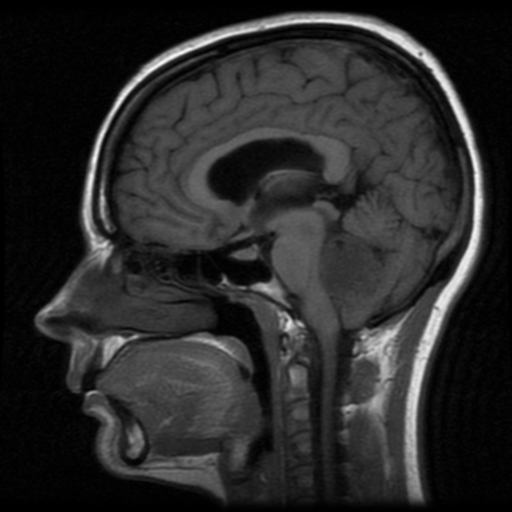

Para la elaboración del código, utilizaremos ciertas librerías que nos facilitaran la lectura, procesamiento y visualización de las imágenes. Emplearemos OpenCV, Numpy y Matplotlib.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Después, cargamos la imagen utilizando OpenCV en Python mediante ***cv2.imread(“RMcerebral.jpg”)***.  Utilizaremos la función ***.shape*** para poder obtener las dimensiones de la imagen, lo cual utilizaremos más adelante.


In [ ]:
RMcerebral = cv2.imread("RMcerebral.jpg")
alto, ancho = RMcerebral.shape[:2]

Posteriormente, aplicaremos la modificación geométrica de traslación en la imagen, en donde, desplazaremos 50 píxeles en el eje horizontal (x) y 30 píxeles en el eje vertical (y). La traslación nos permite mover todos los píxeles de la imagen a una nueva posición definida sin alterar ni su tamaño.

In [ ]:
# TRASLACION CON X = 50 y Y = 30
# tx = derecha/izq, ty = abajo/arriba
tx1 = 50
ty1 = 30

M1_traslacion = np.float32([[1, 0, tx1], [0, 1, ty1]]) # matriz de traslacion
imagen_traslacionent = cv2.warpAffine(RMcerebral, M1_traslacion, (ancho, alto))

En el código presentamos lo que se conoce como *“Matriz de traslación”*, la cual, nos permite representar la modificación de la imagen sin alterar la forma ni el tamaño de la imagen original. Definimos valores unitarios ( 1 ) en la diagonal para no permitir cambios en la escala y que solo estos se realicen en los ejes x y y (tx y ty).

Utilizamos la función ***cv2.warpAffine*** que se utiliza para aplicar transformaciones geométricas a una imagen a partir de una matriz de transformación. Las dimensiones obtenidas por el ***.shape*** se utilizan directamente en esta función, especificando  el tamaño de la imagen de salida mediante los parámetros *(alto, ancho)*. Esto asegura que la imagen transformada conserve las mismas dimensiones que la imagen original, evitando deformaciones.

Volveremos a aplicar la modificación geométrica de traslación en la imagen, pero ahora utilizaremos valores decimales, en este caso, desplazaremos 10.5 pixeles en el eje horizontal (x) y 15.5 pixeles en el eje vertical (y).

In [ ]:
# TRASLACION CON DECIMALES X = 20.5 y Y = 15.5
# tx = derecha/izq, ty = abajo/arriba
tx2 = 20.5
ty2 = 15.5

M2_traslacion = np.float32([[1, 0, tx2], [0, 1, ty2]]) # matriz de traslacion
imagen_traslaciondec = cv2.warpAffine(RMcerebral, M2_traslacion, (ancho, alto), flags=cv2.INTER_LINEAR)

El parámetro flags define el método de interpolación empleada en la transformación de la imagen, en este caso, la interpolación lineal (***cv2.INTER_LINEAR***) se calcula valores de nuevos píxeles cuando los píxeles no coinciden exactamente con posiciones enteras, como al trabajar con traslaciones con decimales.

Ahora, visualizando las imágenes transformadas:

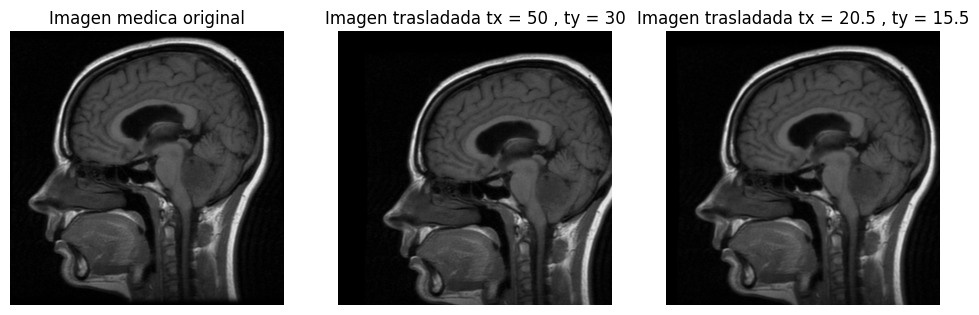

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1,3,1)
plt.imshow(RMcerebral, cmap="gray")
plt.title("Imagen medica original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(imagen_traslacionent, cmap="gray")
plt.title("Imagen trasladada tx = 50 , ty = 30")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(imagen_traslaciondec, cmap="gray")
plt.title("Imagen trasladada tx = 20.5 , ty = 15.5")
plt.axis("off")

plt.show()

### **EJERCICIO 2.** ***Rotación***

Para este ejercicio trabajaremos con las mismas librerías y con la misma imagen ya previamente cargada en nuestro código.

Posteriormente, aplicaremos la modificación geométrica de rotación en la imagen, en donde, rotaremos la imagen 45° alrededor del centro de la imagen. Para la obtención del centro dividiremos las dimensiones de nuestras imágenes a la mitad, que obtuvimos previamente de la función ***.shape***.

In [ ]:
# ROTACION 45° DE SU CENTRO
centro = (ancho//2, alto//2)
M3_rotacion = cv2.getRotationMatrix2D(centro, 45, 1)
imagen_rotada = cv2.warpAffine(RMcerebral, M3_rotacion, (ancho,alto))

Utilizamos la función ***cv2.getRotationMatriz2D*** la cual se utiliza para definir una transformación geométrica que permite girar una imagen en torno a un punto específico, en este caso, definimos los parámetros con respecto al centro y con 45° de rotación, el 1 nos indica el factor de escala.



Ahora, visualizando la imagen rotada obtenida:

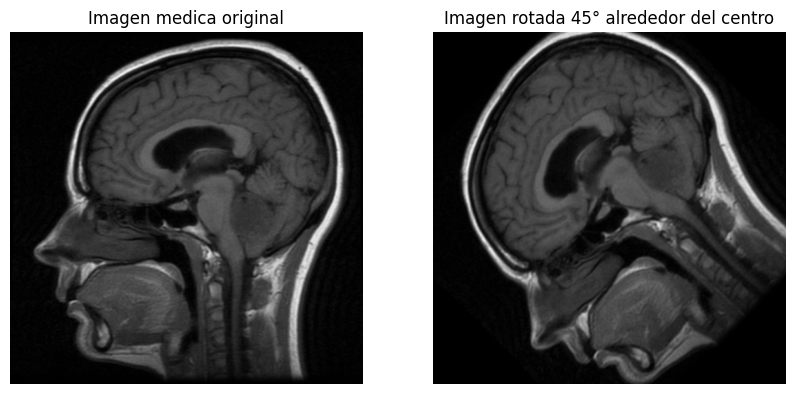

In [ ]:
plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
plt.imshow(RMcerebral, cmap="gray")
plt.title("Imagen medica original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_rotada, cmap="gray")
plt.title("Imagen rotada 45° alrededor del centro")
plt.axis("off")

plt.show()

### **EJERCICIO 3.** ***Escala***

Para este ejercicio igualmente trabajaremos con las mismas librerías y con la misma imagen ya previamente cargada en nuestro código.

Posteriormente, aplicaremos la modificación geométrica de escala en la imagen, en donde, escalaremos la imagen a un 150% y 50% de tamaño. Para poder realizar aumentar o reducir las dimensiones de la imagen utilizaremos la función ***.resize*** y lo obtenido con la función ***.shape***, en donde multiplicamos estos valores por los porcentajes por los cuales queremos modificar drásticamente el tamaño de la imagen.

In [ ]:
escala_150 = cv2.resize(RMcerebral, (int(ancho*1.5), int(alto*1.5)), interpolation=cv2.INTER_LINEAR)
escala_50 = cv2.resize(RMcerebral, (int(ancho*0.5), int(alto*0.5)), interpolation=cv2.INTER_LINEAR)

Ahora, visualizando las imágenes escaladas obtenidas:

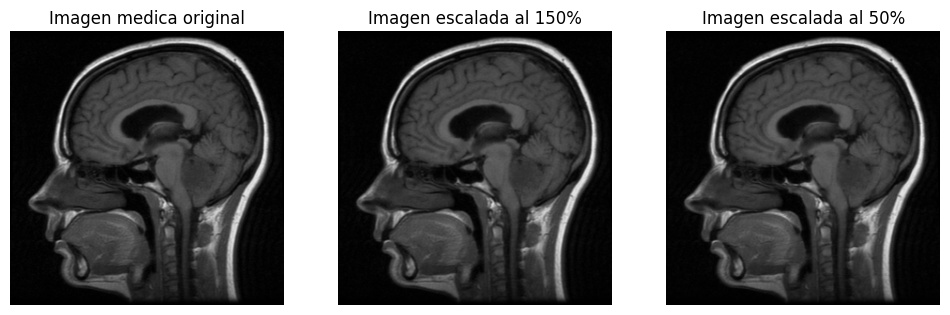

In [ ]:
plt.figure(figsize=(12, 6))
plt.subplot(1,3,1)
plt.imshow(RMcerebral, cmap="gray")
plt.title("Imagen medica original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(escala_150, cmap="gray")
plt.title("Imagen escalada al 150%")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(escala_50, cmap="gray")
plt.title("Imagen escalada al 50%")
plt.axis("off")

plt.show()

Aunque se aplican correctamente los escalamientos, la visualización mediante subplots en Matplotlib puede hacer que las imágenes aparenten tener el mismo tamaño, por lo que se puede comprobar mediante la función ***.shape*** para cada escalado.

In [ ]:
print(RMcerebral.shape[:2])
print(escala_150.shape[:2])
print(escala_50.shape[:2])

(512, 512)
(768, 768)
(256, 256)


### **EJERCICIO II. ECUALIZACIÓN DE HISTOGRAMA**

Primero se importan las librerías necesarias para ejecutar el código y mostrar las gráficas comparativas de imagen ecualizada y la imágen original.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Posteriormente, se carga la imagen correspondiente utilizando la función*** cv2.imread()***, la cual permite leer la imagen desde el archivo y almacenarla en una matriz. Se incluye una condición if img is None para verificar que la imagen se haya cargado.

In [ ]:
img = cv2.imread('tc.coronal.jpg')
if img is None:
    print("Error: No se pudo cargar la imagen.")
    exit()

Para esta práctica se utilizó una imagen de tomografía computarizada en vista coronal, la cual fue obtenida de la plataforma Radiopaedia. Aunque la imagen ya se encontraba en B&N, fue necesario procesarla dentro del código y convertirla a escala de grises para asegurar que la imagen estuviera en el formato adecuado.

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Se calcula el histograma de la imagen con la función ***cv2.calcHist()***, la cual permite obtener la distribución de los niveles de intensidad de la imagen. Trabaja sin máscara, con 256 bins y en un rango de intensidades de 0 a 256. Luego se aplica la ecualización de histograma con ***cv2.equalizeHist()*** la cual toma la imagen en B&N como entrada y genera una nueva imagen en la que los niveles de intensidad están más distribuidos, permitiendo así resaltar detalles que no eran visibles en la imagen original.

Una vez obtenida la imagen ecualizada, se calcula su histograma utilizando nuevamente la función ***cv2.calcHist()***, lo que permite comparar la distribución de intensidades antes y después de la ecualización.

In [ ]:
# Histograma original
hist_original = cv2.calcHist([gray], [0], None, [256], [0,256])

# Ecualización de histograma
equalized = cv2.equalizeHist(gray)

# Histograma ecualizado
hist_equalized = cv2.calcHist([equalized], [0], None, [256], [0,256])

Por último se imprimen los datos de los niveles de intensidad graficados para permitir su comparación entre la imagen original y la imagen ecualizada.

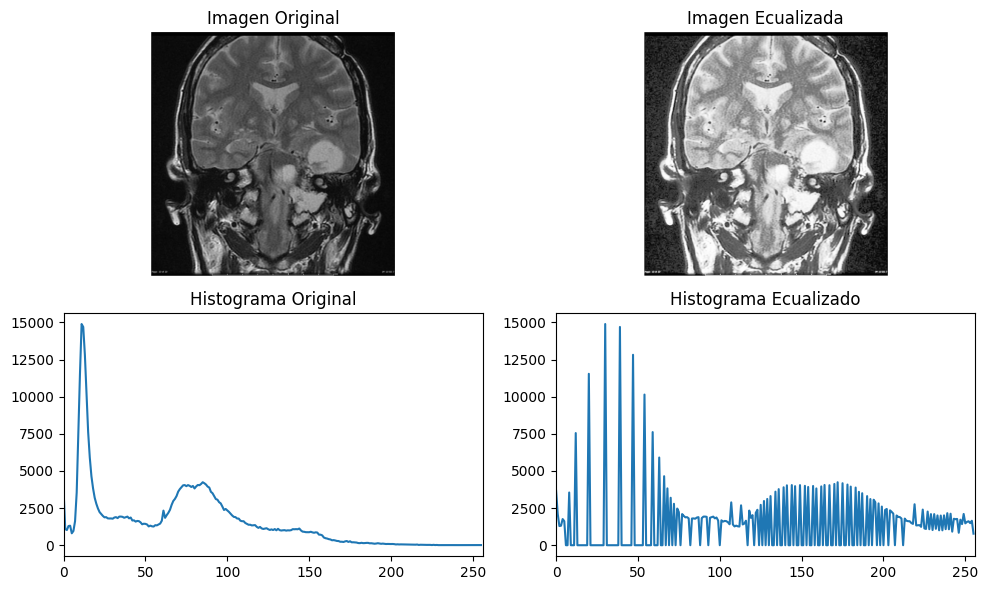

In [ ]:
# Mostrar resultados
plt.figure(figsize=(10,6))

# Imagen original
plt.subplot(2,2,1)
plt.imshow(gray, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

# Imagen ecualizada
plt.subplot(2,2,2)
plt.imshow(equalized, cmap='gray')
plt.title('Imagen Ecualizada')
plt.axis('off')

# Histograma original
plt.subplot(2,2,3)
plt.plot(hist_original)
plt.title('Histograma Original')
plt.xlim([0,256])

# Histograma ecualizado
plt.subplot(2,2,4)
plt.plot(hist_equalized)
plt.title('Histograma Ecualizado')
plt.xlim([0,256])

plt.tight_layout()
plt.show()